# Structure of packings

The growth rate decides the structure of a packing. This notebook makes two packings of 4000 equal spheres, one by fast compression (random close packing) and one by slow compression, and compares them with the tools in `spheropack.analysis`: the pair distribution function, bond-orientational order, crystallinity, contact numbers, and density profiles next to walls.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import spheropack as sp
from spheropack import analysis
from spheropack.plotting import plot_section

fast = sp.pack(n=4000, density="max", growth_rate=0.02, seed=1)
slow = sp.pack(n=4000, density="max", growth_rate=0.0005, seed=1)
for name, p in [("fast", fast), ("slow", slow)]:
    print(f"{name}: density {p.density:.4f}, {p.n_collisions / p.n:.0f} collisions per sphere, {p.wall_time:.0f} s")

fast: density 0.6412, 4296 collisions per sphere, 67 s
slow: density 0.6520, 68154 collisions per sphere, 981 s


## Pair distribution function

$g(r)$ is the density of sphere centres at distance $r$ from a sphere, relative to the mean density. In a jammed random packing it has a delta-like peak at contact ($r = d$), a split second peak at $r = \sqrt{3}\,d$ and $r = 2d$ (two spheres in contact with a common neighbour, in a plane or in a line), and decaying oscillations. A crystal shows sharp peaks at the lattice distances ($\sqrt 2\, d$, $\sqrt 3\, d$, $2d$ for FCC).

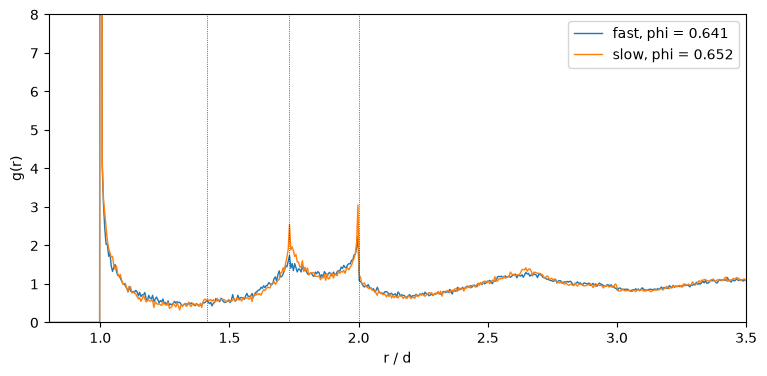

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, p in [("fast", fast), ("slow", slow)]:
    d = p.diameters.mean()
    rdf = analysis.radial_distribution(p, r_max=3.5 * d, bins=700)
    ax.plot(rdf.r / d, rdf.g, label=f"{name}, phi = {p.density:.3f}", lw=1)
for x in (np.sqrt(2), np.sqrt(3), 2):
    ax.axvline(x, color="k", lw=0.5, ls=":")
ax.set_xlim(0.8, 3.5); ax.set_ylim(0, 8)
ax.set_xlabel("r / d"); ax.set_ylabel("g(r)"); ax.legend();

## Bond-orientational order and crystallinity

Steinhardt's $q_6$ measures the local orientational order of the bonds to the neighbours of a sphere: 0.575 for FCC, 0.485 for HCP, around 0.35 to 0.45 in random packings. The ten Wolde-Frenkel criterion (`analysis.crystalline`) marks a sphere as crystalline when at least 7 of its bonds connect it to neighbours with a similar orientation of local order.

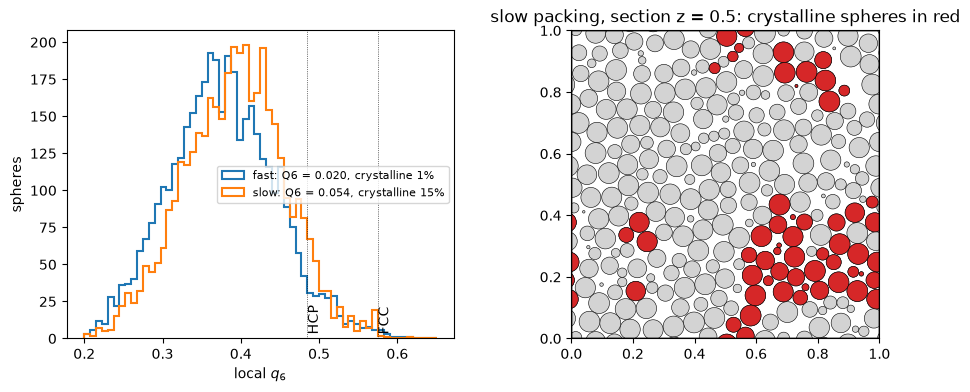

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, p in [("fast", fast), ("slow", slow)]:
    q6 = analysis.bond_order(p, l=6)
    cryst = analysis.crystalline(p)
    axes[0].hist(q6.local, bins=60, range=(0.2, 0.65), histtype="step", lw=1.5,
                 label=f"{name}: Q6 = {q6.global_value:.3f}, crystalline {100 * cryst.mean():.0f}%")
for x, lab in ((0.575, "FCC"), (0.485, "HCP")):
    axes[0].axvline(x, color="k", lw=0.5, ls=":"); axes[0].text(x, 5, lab, rotation=90)
axes[0].set_xlabel("local $q_6$"); axes[0].set_ylabel("spheres"); axes[0].legend(fontsize=8)

cryst = analysis.crystalline(slow)
plot_section(slow, axis=2, ax=axes[1], color="lightgray")
p_c = sp.Packing(**{**slow.__dict__, "positions": slow.positions[cryst], "radii": slow.radii[cryst]})
plot_section(p_c, axis=2, ax=axes[1], color="tab:red")
axes[1].set_title("slow packing, section z = 0.5: crystalline spheres in red");

## Contacts

In a jammed packing every force-bearing sphere touches on average close to $2D = 6$ others (isostatic); rattlers carry no force. The distribution of contact numbers differs between random and crystalline packings: crystals have up to 12 contacts.

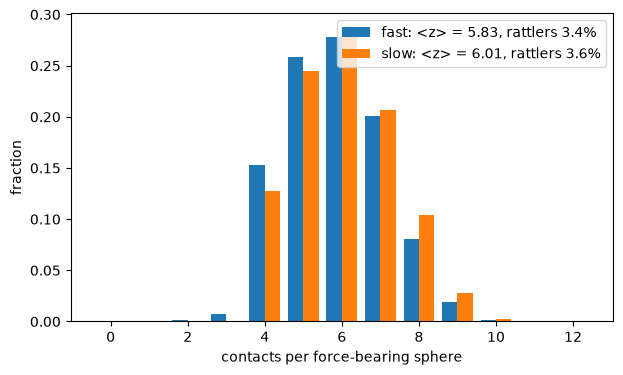

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for k, (name, p) in enumerate([("fast", fast), ("slow", slow)]):
    rat = analysis.rattlers(p)
    z = analysis.contact_numbers(p, tol=1e-6)[~rat]
    counts = np.bincount(z, minlength=13)
    ax.bar(np.arange(13) + 0.4 * k - 0.2, counts / counts.sum(), width=0.4,
           label=f"{name}: <z> = {z.mean():.2f}, rattlers {100 * rat.mean():.1f}%")
ax.set_xlabel("contacts per force-bearing sphere"); ax.set_ylabel("fraction"); ax.legend();

## Layering next to a wall

Near a flat wall spheres order in layers. The exact local solid fraction (`analysis.density_profile`, spheres sliced analytically) shows the layers as oscillations that decay over a few diameters. Here a slab between two walls, periodic in the other directions, packed to jamming:

overall density 0.6365


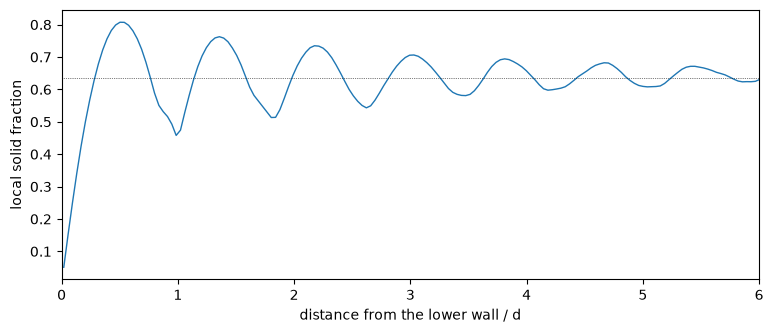

In [5]:
slab = sp.Box([1.0, 1.0, 2.0], periodic=[True, True, False])
s = sp.pack(n=8000, density="max", container=slab, seed=2)
z, phi = analysis.density_profile(s, axis=2, bins=800)
d = s.diameters.mean()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(z / d, phi, lw=1)
ax.axhline(s.density, color="k", lw=0.5, ls=":")
ax.set_xlabel("distance from the lower wall / d"); ax.set_ylabel("local solid fraction")
ax.set_xlim(0, 6)
print(f"overall density {s.density:.4f}")